# Baseline models 

1. TF-IDF + modèles linéaire 
2. GloVe + modèles linéaire

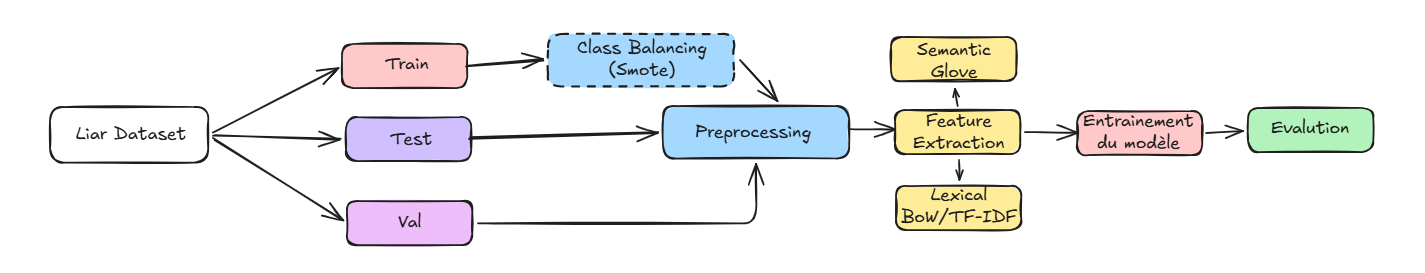

# 0. Rappel de l’architecture globale du pipeline

Ce notebook s’inscrit dans le pipeline global suivant pour la détection de fake news politiques à partir du dataset LIAR :

![Architecture globale](../images/architecture_pipeline.png)

1. **LIAR Dataset**  
   Le dataset LIAR est fourni avec trois splits canoniques : `train`, `val`, `test`.  
   Dans `EDA_LIAR.ipynb`, nous avons :
   - fusionné les fichiers bruts pour faire l’EDA,  
   - nettoyé le texte (`statement`) et les métadonnées,  
   - créé un label binaire `label_binary` (FAKE vs REAL),  
   - puis re‑sauvegardé les splits préparés dans `data/traitees/liar_train.parquet`, `liar_val.parquet`, `liar_test.parquet`.

2. **Class Balancing (SMOTE)**  
   Le schéma global prévoit un module de ré‑équilibrage des classes via SMOTE (ou techniques similaires) sur le split *train* uniquement.  
   Dans ce notebook de baselines, nous n’appliquons **pas encore** SMOTE :  
   - le léger déséquilibre est géré via `class_weight="balanced"` dans les modèles linéaires,  
   - cela nous permet de garder un pipeline simple et rapide pour servir de référence.  
   Le bloc *Class Balancing* reste donc une **brique optionnelle** que nous pourrons activer dans un second temps si besoin.

3. **Preprocessing**  
   Le pré‑traitement “global” (normalisation du texte, gestion des valeurs manquantes, calcul de `label_binary`) a déjà été réalisé dans `EDA_LIAR.ipynb`.  
   Ici, le pré‑traitement spécifique aux modèles est encapsulé directement dans les pipelines scikit‑learn :
   - tokenisation + construction du vocabulaire via `TfidfVectorizer`,
   - pondération TF‑IDF des n‑grams (1 ou 2 mots).

4. **Feature Extraction – Branche lexicale (BoW / TF‑IDF)**  
   Le schéma distingue deux branches :
   - **Branche lexicale** : BoW / TF‑IDF
   - **Branche sémantique** : embeddings type GloVe (et plus tard DistilBERT / RoBERTa)

   Ce notebook se concentre **uniquement sur la branche lexicale** :
   - représentation TF‑IDF des `statement`,
   - aucune feature dense type GloVe utilisée ici.

5. **Entraînement du modèle (ce notebook)**  
   `Modeles_de_Base.ipynb` instancie et entraîne deux modèles linéaires classiques sur la représentation TF‑IDF :
   - **TF‑IDF + Logistic Regression**
   - **TF‑IDF + LinearSVC (SVM linéaire)**

   Les deux modèles sont :
   - optimisés via `GridSearchCV` (3‑fold CV) sur la métrique **F1 pondéré** (`f1_weighted`) en classification binaire,  
   - évalués sur le jeu de test LIAR avec :
     - Accuracy,
     - F1 pondéré,
     - *generalization gap* (Accuracy_train − Accuracy_test), pour suivre la même logique que Hasan et al. (2025) sur les “generalization gaps” de LIAR.

6. **Évaluation**  
   À la fin du notebook, nous :
   - affichons les rapports de classification (précision / rappel / F1 par classe),
   - comparons les scores des deux baselines,
   - sauvegardons les modèles entraînés dans `models/` pour les réutiliser :
     - dans `Evaluation_Hors_Domaine.ipynb` (test sur BuzzFeed fake/real),
     - dans `Interpretabilite_Biais.ipynb` (LIME / SHAP et analyse des biais par parti, speaker, sujet).

## 1. Imports et chargement des données

In [96]:
import re
import numpy as np
from pathlib import Path
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [97]:
DATA_DIR = Path("../data")
TRAITEES_DIR = DATA_DIR / "traitees"

df_train = pd.read_parquet(TRAITEES_DIR / "liar_train.parquet")
df_val   = pd.read_parquet(TRAITEES_DIR / "liar_val.parquet")
df_test  = pd.read_parquet(TRAITEES_DIR / "liar_test.parquet")

X_train, y_train = df_train["statement"], df_train["label_binary"]
X_val,   y_val   = df_val["statement"],   df_val["label_binary"]
X_test,  y_test  = df_test["statement"],  df_test["label_binary"]

print("Taille train :", len(X_train))
print("Taille val   :", len(X_val))
print("Taille test  :", len(X_test))

Taille train : 10240
Taille val   : 1284
Taille test  : 1267


## 2. Pré‑traitement texte (bloc “Preprocessing”)
Le nettoyage plus lourd a été fait dans `EDA_LIAR.ipynb`, donc ici on garde un pré-traitement léger.

In [98]:
def preprocess_text(series: pd.Series) -> pd.Series:
    """
    Prétraitement minimal : trim + passage en minuscules.
    """
    return series.astype(str).str.strip().str.lower()

X_train_clean = preprocess_text(X_train)
X_val_clean   = preprocess_text(X_val)
X_test_clean  = preprocess_text(X_test)

## 3. Construction explicite des pipelines (TF-IDF + SMOTE + LR / SVM)
### 3.1 Fonction d’évaluation commune

In [99]:
def evaluate_model(model, X_train, y_train, X_eval, y_eval, eval_name: str):
    """
    Calcule accuracy, F1 pondéré et generalization gap pour un modèle donné.
    """
    # train
    y_pred_train = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_pred_train)
    f1w_train = f1_score(y_train, y_pred_train, average="weighted")

    # eval (val ou test)
    y_pred_eval = model.predict(X_eval)
    acc_eval = accuracy_score(y_eval, y_pred_eval)
    f1w_eval = f1_score(y_eval, y_pred_eval, average="weighted")

    gap = acc_train - acc_eval

    print(f"\n=== {eval_name} ===")
    print(f"Accuracy train : {acc_train:.3f}")
    print(f"Accuracy {eval_name} : {acc_eval:.3f}")
    print(f"Generalization gap (train - {eval_name}) : {gap:.3f}")
    print(f"F1 pondéré train : {f1w_train:.3f}")
    print(f"F1 pondéré {eval_name} : {f1w_eval:.3f}")
    print("\nClassification report :\n")
    print(classification_report(y_eval, y_pred_eval, digits=3))
    print("Matrice de confusion :\n", confusion_matrix(y_eval, y_pred_eval))

    return {
        "acc_train": acc_train,
        f"acc_{eval_name}": acc_eval,
        "f1w_train": f1w_train,
        f"f1w_{eval_name}": f1w_eval,
        "gap": gap,
    }

### 3.2 Pipeline 1 – TF‑IDF + SMOTE + LogisticRegression

In [100]:
# Bloc "Feature Extraction – Branche lexicale (TF‑IDF)" + "Class Balancing (SMOTE)" + "Entraînement du modèle"
pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer()),          # tokenisation, vocabulaire, pondération TF‑IDF
    ("smote", SMOTE(random_state=42)),     # ré-équilibrage FAKE / REAL
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight=None,                 # SMOTE gère le déséquilibre
        solver="liblinear",
        n_jobs=-1,
    )),
])

param_grid_lr = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 5],
    "tfidf__max_df": [0.9, 1.0],
    "clf__C": [0.1, 1.0, 10.0],
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2,
)

print("GridSearch TF-IDF + SMOTE + LogisticRegression (3-fold CV, F1 pondéré)...")
grid_lr.fit(X_train_clean, y_train)

print("Meilleurs hyperparamètres LR :", grid_lr.best_params_)
print("Meilleur score F1 pondéré (CV train) :", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_

GridSearch TF-IDF + SMOTE + LogisticRegression (3-fold CV, F1 pondéré)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits


c:\Users\Franck\Documents\grp3_projet3_data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Meilleurs hyperparamètres LR : {'clf__C': 1.0, 'tfidf__max_df': 0.9, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Meilleur score F1 pondéré (CV train) : 0.6127188635068251


### 3.3 Pipeline 2 – TF‑IDF + SMOTE + LinearSVC

In [101]:
pipe_svm = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("smote", SMOTE(random_state=42)),
    ("clf", LinearSVC()),
])

param_grid_svm = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 5],
    "tfidf__max_df": [0.9, 1.0],
    "clf__C": [0.1, 1.0, 10.0],
}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid_svm,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2,
)

print("GridSearch TF-IDF + SMOTE + LinearSVC (3-fold CV, F1 pondéré)...")
grid_svm.fit(X_train_clean, y_train)

print("Meilleurs hyperparamètres SVM :", grid_svm.best_params_)
print("Meilleur score F1 pondéré (CV train) :", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_

GridSearch TF-IDF + SMOTE + LinearSVC (3-fold CV, F1 pondéré)...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Meilleurs hyperparamètres SVM : {'clf__C': 0.1, 'tfidf__max_df': 0.9, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Meilleur score F1 pondéré (CV train) : 0.61399518808407


## 4. Évaluation sur validation et test

In [102]:
print("\n##### Logistic Regression #####")
metrics_lr_val  = evaluate_model(best_lr,  X_train_clean, y_train, X_val_clean,  y_val,  "val")
metrics_lr_test = evaluate_model(best_lr,  X_train_clean, y_train, X_test_clean, y_test, "test")

print("\n##### LinearSVC #####")
metrics_svm_val  = evaluate_model(best_svm, X_train_clean, y_train, X_val_clean,  y_val,  "val")
metrics_svm_test = evaluate_model(best_svm, X_train_clean, y_train, X_test_clean, y_test, "test")


##### Logistic Regression #####

=== val ===
Accuracy train : 0.844
Accuracy val : 0.627
Generalization gap (train - val) : 0.217
F1 pondéré train : 0.844
F1 pondéré val : 0.626

Classification report :

              precision    recall  f1-score   support

           0      0.617     0.588     0.602       616
           1      0.636     0.663     0.649       668

    accuracy                          0.627      1284
   macro avg      0.626     0.625     0.625      1284
weighted avg      0.627     0.627     0.626      1284

Matrice de confusion :
 [[362 254]
 [225 443]]

=== test ===
Accuracy train : 0.844
Accuracy test : 0.632
Generalization gap (train - test) : 0.212
F1 pondéré train : 0.844
F1 pondéré test : 0.632

Classification report :

              precision    recall  f1-score   support

           0      0.579     0.579     0.579       553
           1      0.674     0.674     0.674       714

    accuracy                          0.632      1267
   macro avg      0.626    

## 5. Implémentation pratique de la branche GloVe
Cette branche capture plus de sémantique (synonymes, similarité sémantique) par rapport à TF-IDF.
### 6.1 Télécharger et charger GloVe

In [103]:
GLOVE = DATA_DIR / "embeddings"
GLOVE_PATH = GLOVE / "dolma_300_2024_1.2M.100_combined.txt"
EMB_DIM = 300

def load_glove(path: str, emb_dim: int = 50) -> dict:
    """
    Charge les embeddings GloVe dans un dict {mot: vecteur np.array}.
    """
    glove_file = Path(path)
    if not glove_file.exists():
        print(f"⚠️ {path} introuvable. Ignorer ou télécharger le fichier Gloves...")
        return {}
        
    embeddings_index = {}
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            values = line.rstrip().split(" ")
            word = values[0]
            coefs = np.asarray(values[1:], dtype="float32")
            if coefs.shape[0] == emb_dim:
                embeddings_index[word] = coefs
    print(f"Chargé {len(embeddings_index)} vecteurs GloVe ({emb_dim}d).")
    return embeddings_index

emb_index = load_glove(GLOVE_PATH, EMB_DIM)

Chargé 1200001 vecteurs GloVe (300d).


### 5.2 Transformer une phrase LIAR en vecteur GloVe (Mean Pooling)

In [104]:
TOKEN_PATTERN = re.compile(r"\w+")

def sent_to_glove_vec(sentence: str, emb_index: dict, emb_dim: int) -> np.ndarray:

    # Convertit une phrase en vecteur dense en moyennant les embeddings des mots GloVe présents.

    tokens = TOKEN_PATTERN.findall(sentence.lower())
    if not tokens:
        return np.zeros(emb_dim, dtype="float32")

    vecs = [emb_index[t] for t in tokens if t in emb_index]
    if not vecs:
        return np.zeros(emb_dim, dtype="float32")
    return np.mean(vecs, axis=0)

def corpus_to_glove_matrix(texts, emb_index: dict, emb_dim: int) -> np.ndarray:
    
    # Applique sent_to_glove_vec à une série / liste de textes.
    
    mat = np.vstack([sent_to_glove_vec(t, emb_index, emb_dim) for t in texts])

    return mat

X_train_glove = corpus_to_glove_matrix(X_train_clean, emb_index, EMB_DIM)
X_val_glove   = corpus_to_glove_matrix(X_val_clean,   emb_index, EMB_DIM)
X_test_glove  = corpus_to_glove_matrix(X_test_clean,  emb_index, EMB_DIM)

print(X_train_glove.shape, X_val_glove.shape, X_test_glove.shape)

(10240, 300) (1284, 300) (1267, 300)


### 5.3 Modèles à tester sur la branche GloVe
#### Option A : GloVe → Logistic Regression

In [105]:
logreg_glove = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1,
    solver="liblinear",
)

param_grid_glove_lr = {
    "C": [0.1, 1.0, 10.0],
}

grid_glove_lr = GridSearchCV(
    logreg_glove,
    param_grid_glove_lr,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2,
)

grid_glove_lr.fit(X_train_glove, y_train)

print("Meilleurs params GloVe+LR :", grid_glove_lr.best_params_)
print("Meilleur F1 pondéré (CV train) :", grid_glove_lr.best_score_)

best_glove_lr = grid_glove_lr.best_estimator_

Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\Users\Franck\Documents\grp3_projet3_data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Meilleurs params GloVe+LR : {'C': 1.0}
Meilleur F1 pondéré (CV train) : 0.6033562334592657


#### Option B : GloVe → SMOTE → Logistic Regression

In [106]:
pipe_glove_lr = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight=None,
        solver="liblinear",
        n_jobs=-1,
    )),
])

param_grid_pipe_glove_lr = {
    "clf__C": [0.1, 1.0, 10.0],
}

grid_pipe_glove_lr = GridSearchCV(
    pipe_glove_lr,
    param_grid_pipe_glove_lr,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1,
    verbose=2,
)

grid_pipe_glove_lr.fit(X_train_glove, y_train)
best_glove_lr_smote = grid_pipe_glove_lr.best_estimator_

print("\n##### GloVe + LR #####")
metrics_glove_lr = evaluate_model(best_glove_lr, X_train_glove, y_train, X_test_glove, y_test, "test")
print("\n##### GloVe + SMOTE + LR #####")
metrics_glove_sm = evaluate_model(best_glove_lr_smote, X_train_glove, y_train, X_test_glove, y_test, "test")

Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\Users\Franck\Documents\grp3_projet3_data\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



##### GloVe + LR #####

=== test ===
Accuracy train : 0.635
Accuracy test : 0.599
Generalization gap (train - test) : 0.036
F1 pondéré train : 0.636
F1 pondéré test : 0.600

Classification report :

              precision    recall  f1-score   support

           0      0.538     0.571     0.554       553
           1      0.651     0.620     0.636       714

    accuracy                          0.599      1267
   macro avg      0.595     0.596     0.595      1267
weighted avg      0.602     0.599     0.600      1267

Matrice de confusion :
 [[316 237]
 [271 443]]

##### GloVe + SMOTE + LR #####

=== test ===
Accuracy train : 0.632
Accuracy test : 0.599
Generalization gap (train - test) : 0.033
F1 pondéré train : 0.634
F1 pondéré test : 0.600

Classification report :

              precision    recall  f1-score   support

           0      0.538     0.573     0.555       553
           1      0.652     0.619     0.635       714

    accuracy                          0.599      1267


## 6. Sauvegarde explicite des modèles

In [107]:
import joblib

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Sauvegarde des modèles TF-IDF
joblib.dump(best_lr,  MODELS_DIR / "liar_tfidf_smote_logreg_label_binary.joblib")
joblib.dump(best_svm, MODELS_DIR / "liar_tfidf_smote_linearsvc_label_binary.joblib")

# Sauvegarde des modèles GloVe (si existants)
if 'best_glove_lr' in locals():
    joblib.dump(best_glove_lr, MODELS_DIR / "liar_glove_logreg_label_binary.joblib")
if 'best_glove_lr_smote' in locals():
    joblib.dump(best_glove_lr_smote, MODELS_DIR / "liar_glove_smote_logreg_label_binary.joblib")

print("Tous les modèles ont été sauvegardés dans", MODELS_DIR)


Tous les modèles ont été sauvegardés dans ..\models


## 7. Tableau Synthétique Final

In [108]:
import pandas as pd

# Liste pour stocker tous nos résultats
results = []

# Dictionnaire de correspondance (Variable, Nom d'affichage, Features, Balancing)
model_configs = [
    ("metrics_lr_test",  "TF-IDF + LogReg",    "Uni/Bi-grams", "class_weight"),
    ("metrics_svm_test", "TF-IDF + LinearSVC", "Uni/Bi-grams", "SMOTE"),
    ("metrics_glove_lr", "GloVe + LogReg",     "Avg (300d)",    "class_weight"),
    ("metrics_glove_sm", "GloVe + SMOTE + LR", "Avg (300d)",    "SMOTE")
]

for var_name, model_name, features, balancing in model_configs:
    if var_name in locals():
        m = locals()[var_name]
        results.append({
            "Modèle": model_name,
            "Features": features,
            "Balancing": balancing,
            "Acc (test)": f"{m['acc_test']:.3f}",
            "F1w (test)": f"{m['f1w_test']:.3f}",
            "Gap train-test (Acc)": f"{m['gap']:.3f}"
        })
    else:
        results.append({
            "Modèle": model_name,
            "Features": features,
            "Balancing": balancing,
            "Acc (test)": "[Attente]",
            "F1w (test)": "[Attente]",
            "Gap train-test (Acc)": "[Attente]"
        })

# Création et affichage du DataFrame récapitulatif
df_results = pd.DataFrame(results)
display(df_results)


,Modèle,Features,Balancing,Acc (test),F1w (test),Gap train-test (Acc)
0,TF-IDF + LogReg,Uni/Bi-grams,class_weight,0.632,0.632,0.212
1,TF-IDF + LinearSVC,Uni/Bi-grams,SMOTE,0.631,0.632,0.200
2,GloVe + LogReg,Avg (300d),class_weight,0.599,0.600,0.036
3,GloVe + SMOTE + LR,Avg (300d),SMOTE,0.599,0.600,0.033


### Analyse et Conclusion

Les baselines linéaires atteignent autour de 0,63 d’accuracy et F1 pondéré avec TF‑IDF (LogReg et LinearSVC), au prix d’un écart de généralisation important entre train et test (≈ 0,20–0,21), ce qui suggère un léger surapprentissage sur LIAR malgré la régularisation et le class_weight.



​---

La branche GloVe Dolma 300d reste légèrement en dessous en performance brute (≈ 0,60 d’accuracy/F1), mais avec un gap beaucoup plus faible (≈ 0,03), indiquant des représentations plus stables et mieux régularisées. Ces résultats fournissent une ligne de base robuste : TF‑IDF donne le meilleur score in‑domain, tandis que GloVe fournit une alternative plus « lisse » à explorer pour les scénarios hors‑domaine et pour des modèles non linéaires ou contextuels plus complexes.